In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
%matplotlib inline

df = pd.read_csv("C:\\Users\\admin\\Downloads\\Neural-Network-using-PyTorch-main (1)\\Neural-Network-using-PyTorch-main\\Class-Code-U1\\income.csv")

In [2]:
df.head()

,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,27,Male,HS-grad,9,Never-married,Private,Craft-repair,40,<=50K,0
1,47,Male,Masters,14,Married,Local-gov,Exec-managerial,50,>50K,1
2,59,Male,HS-grad,9,Divorced,Self-emp,Prof-specialty,20,<=50K,0
3,38,Female,Prof-school,15,Never-married,Federal-gov,Prof-specialty,57,>50K,1
4,64,Female,11th,7,Widowed,Private,Farming-fishing,40,<=50K,0


In [3]:
len(df)

30000

In [4]:
df.tail()

,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
29995,45,Male,Masters,14,Married,State-gov,Prof-specialty,60,>50K,1
29996,33,Male,HS-grad,9,Married,Private,Machine-op-inspct,40,>50K,1
29997,47,Male,Prof-school,15,Married,Private,Prof-specialty,55,>50K,1
29998,32,Female,Some-college,10,Never-married,Private,Adm-clerical,40,<=50K,0
29999,33,Male,Assoc-acdm,12,Married,Self-emp,Exec-managerial,60,>50K,1


In [5]:
df['label'].value_counts()

label
0    21700
1     8300
Name: count, dtype: int64

In [6]:
df.columns

Index(['age', 'sex', 'education', 'education-num', 'marital-status',
       'workclass', 'occupation', 'hours-per-week', 'income', 'label'],
      dtype='object')

In [7]:
cat_cols = ['sex', 'education', 'marital-status', 'workclass', 'occupation']

cont_cols = ['age', 'hours-per-week']

y_col = ['label']

In [8]:
print(f'cat_cols  has {len(cat_cols)} columns')
print(f'cont_cols has {len(cont_cols)} columns')
print(f'y_col     has {len(y_col)} column')

cat_cols  has 5 columns
cont_cols has 2 columns
y_col     has 1 column


In [9]:
for cols in cat_cols:
    df[cols] = df[cols].astype('object')

In [10]:
df.columns


Index(['age', 'sex', 'education', 'education-num', 'marital-status',
       'workclass', 'occupation', 'hours-per-week', 'income', 'label'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30000 non-null  int64 
 1   sex             30000 non-null  object
 2   education       30000 non-null  object
 3   education-num   30000 non-null  int64 
 4   marital-status  30000 non-null  object
 5   workclass       30000 non-null  object
 6   occupation      30000 non-null  object
 7   hours-per-week  30000 non-null  int64 
 8   income          30000 non-null  object
 9   label           30000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 2.3+ MB


In [12]:
df.dtypes

age                int64
sex               object
education         object
education-num      int64
marital-status    object
workclass         object
occupation        object
hours-per-week     int64
income            object
label              int64
dtype: object

In [13]:
df = shuffle(df, random_state=101)
df.reset_index(drop=True, inplace=True)
df.head()

,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,23,Female,HS-grad,9,Never-married,Private,Other-service,50,<=50K,0
1,37,Female,Prof-school,15,Married,State-gov,Prof-specialty,39,>50K,1
2,34,Male,Some-college,10,Divorced,Private,Adm-clerical,40,<=50K,0
3,31,Male,HS-grad,9,Married,Private,Craft-repair,40,>50K,1
4,20,Female,Some-college,10,Never-married,Private,Sales,25,<=50K,0


In [14]:
cat_szs = [df[col].nunique() for col in cat_cols]

emb_szs = [(size, min(50, (size + 1) // 2)) for size in cat_szs]

In [15]:
print(cat_szs)

[2, 14, 6, 5, 12]


In [16]:
print(emb_szs)

[(2, 1), (14, 7), (6, 3), (5, 3), (12, 6)]


In [17]:
for col in cat_cols:
    df[col] = df[col].astype('category')

In [18]:
cats = np.stack([df[col].cat.codes.values for col in cat_cols], axis=1)

In [19]:
print(cats)

[[ 0 10  3  2  6]
 [ 0 12  1  4  7]
 [ 1 13  0  2  0]
 ...
 [ 1 10  1  2  2]
 [ 0  6  3  2  0]
 [ 1  8  5  3  9]]


In [20]:
arr = np.array(df)

In [21]:
cats = np.stack([df[col].cat.codes.values for col in cat_cols], axis=1)

In [22]:
cats[:5]

array([[ 0, 10,  3,  2,  6],
       [ 0, 12,  1,  4,  7],
       [ 1, 13,  0,  2,  0],
       [ 1, 10,  1,  2,  1],
       [ 0, 13,  3,  2,  9]], dtype=int8)

In [23]:
cats = torch.tensor(cats, dtype=torch.int64)

In [24]:
conts = np.stack([df[col].values for col in cont_cols], axis=1)

In [25]:
conts[:5]

array([[23, 50],
       [37, 39],
       [34, 40],
       [31, 40],
       [20, 25]])

In [26]:
conts = torch.tensor(conts, dtype=torch.float32)

In [27]:
conts[:5]

tensor([[23., 50.],
        [37., 39.],
        [34., 40.],
        [31., 40.],
        [20., 25.]])

In [28]:
conts = conts.type(torch.float64)

In [29]:
conts = conts.float()

In [30]:
conts[:5]

tensor([[23., 50.],
        [37., 39.],
        [34., 40.],
        [31., 40.],
        [20., 25.]])

In [31]:
conts = torch.tensor(conts, dtype=torch.float32)

C:\Users\admin\AppData\Local\Temp\ipykernel_13008\646798986.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  conts = torch.tensor(conts, dtype=torch.float32)


In [32]:
conts.dtype

torch.float32

In [36]:
df['income'] = df['income'].astype('category')

In [37]:
y = torch.tensor(df['income'].cat.codes.values, dtype=torch.int64)

In [39]:
y[:5]

tensor([0, 1, 0, 1, 0])

In [40]:
b = 30000
t = 5000

cat_train = cats[:b-t]
cat_test = cats[b-t:b]

con_train = conts[:b-t]
con_test = conts[b-t:b]

y_train = y[:b-t]
y_test = y[b-t:b]

In [41]:
class TabularModel(nn.Module):

    def __init__(self, emb_szs, n_cont, out_sz, layers, p=0.5):
        # Call the parent __init__
        super().__init__()
        
        # Set up the embedding, dropout, and batch normalization layer attributes
        self.embeds = nn.ModuleList([nn.Embedding(ni, nf) for ni,nf in emb_szs])
        self.emb_drop = nn.Dropout(p)
        self.bn_cont = nn.BatchNorm1d(n_cont)
        
        # Assign a variable to hold a list of layers
        layerlist = []
        
        # Assign a variable to store the number of embedding and continuous layers
        n_emb = sum((nf for ni,nf in emb_szs))
        n_in = n_emb + n_cont
        
        # Iterate through the passed-in "layers" parameter (ie, [200,100]) to build a list of layers
        for i in layers:
            layerlist.append(nn.Linear(n_in,i)) 
            layerlist.append(nn.ReLU(inplace=True))
            layerlist.append(nn.BatchNorm1d(i))
            layerlist.append(nn.Dropout(p))
            n_in = i
        layerlist.append(nn.Linear(layers[-1],out_sz))
        
        # Convert the list of layers into an attribute
        self.layers = nn.Sequential(*layerlist)
    
    def forward(self, x_cat, x_cont):
        # Extract embedding values from the incoming categorical data
        embeddings = []
        for i,e in enumerate(self.embeds):
            embeddings.append(e(x_cat[:,i]))
        x = torch.cat(embeddings, 1)
        # Perform an initial dropout on the embeddings
        x = self.emb_drop(x)
        
        # Normalize the incoming continuous data
        x_cont = self.bn_cont(x_cont)
        x = torch.cat([x, x_cont], 1)
        
        # Set up model layers
        x = self.layers(x)
        return x

In [42]:
torch.manual_seed(33)

In [43]:
model = TabularModel(emb_szs, conts.shape[1], 2, [50], p=0.4)

In [44]:
model

TabularModel(
  (embeds): ModuleList(
    (0): Embedding(2, 1)
    (1): Embedding(14, 7)
    (2): Embedding(6, 3)
    (3): Embedding(5, 3)
    (4): Embedding(12, 6)
  )
  (emb_drop): Dropout(p=0.4, inplace=False)
  (bn_cont): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): Linear(in_features=22, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=50, out_features=2, bias=True)
  )
)

In [45]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [46]:
import time
start_time = time.time()

epochs = 300
losses = []

for i in range(epochs):
    i+=1
    y_pred = model(cat_train, con_train)
    loss = criterion(y_pred, y_train)
    losses.append(loss)
    
    # a neat trick to save screen space:
    if i%25 == 1:
        print(f'epoch: {i:3}  loss: {loss.item():10.8f}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f'epoch: {i:3}  loss: {loss.item():10.8f}') # print the last line
print(f'\nDuration: {time.time() - start_time:.0f} seconds') # print the time elapsed

epoch:   1  loss: 0.81377232
epoch:  26  loss: 0.59307522
epoch:  51  loss: 0.51390457
epoch:  76  loss: 0.46117699
epoch: 101  loss: 0.42819440
epoch: 126  loss: 0.39755958
epoch: 151  loss: 0.38082534
epoch: 176  loss: 0.35858384
epoch: 201  loss: 0.34402204
epoch: 226  loss: 0.33575210
epoch: 251  loss: 0.32717407
epoch: 276  loss: 0.32316059
epoch: 300  loss: 0.31616521

Duration: 44 seconds


Text(0.5, 0, 'epoch')

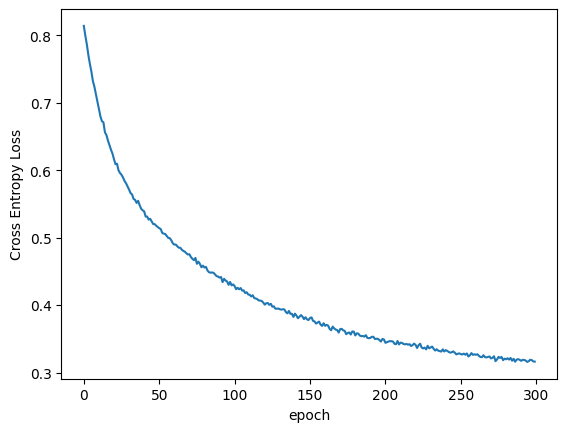

In [49]:
plt.plot(range(epochs), [loss.item() for loss in losses])
plt.ylabel('Cross Entropy Loss')
plt.xlabel('epoch')

In [48]:
with torch.no_grad():
    y_val = model(cat_test, con_test)

loss = criterion(y_val, y_test)

print(f'CE Loss: {loss:.8f}')

CE Loss: 0.33355838


In [50]:
correct = 0

for i in range(len(y_test)):
    if y_val[i].argmax().item() == y_test[i]:
        correct += 1

print(f'{correct} out of {len(y_test)} = {100*correct/len(y_test):.2f}% correct')

4222 out of 5000 = 84.44% correct
